# Ablation: transparent linear risk vs. XGBoost vs. anomaly detectors

**Question.** How does the transparent linear risk scorer (Phase 3), whose
decisions are fully explainable, compare per behavior window with the
statistical detectors it consumes and with a supervised XGBoost model?

**Data.** Seeded simulator (`app/risk/dataset.py`): four IoT devices, 2 hours per
seed, six randomly placed attacks per hour (MQTT flood, port scan, telnet brute
force, MQTT wildcard subscribe, restricted-topic publish). A window is positive if
any attack event falls in it. XGBoost is trained on seeds 100-109 and **all
methods are evaluated on held-out seeds 1-10**.

**Caveat.** This is simulated traffic. The supervised model is trained and tested
on the same generator, so its numbers are an *upper bound*, not a real-world
estimate. Phase 7 repeats the evaluation on labelled public data where available.


In [1]:
import time, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import roc_curve

from app.core.config import BACKEND_ROOT
from app.behavior.config import load_behavior_config
from app.risk.config import load_risk_config
from app.detect.rules import RuleEngine
from app.risk import ablation

OUT = BACKEND_ROOT.parent / "docs" / "evaluation"
behavior = load_behavior_config(BACKEND_ROOT / "config" / "behavior.yaml")
risk = load_risk_config(BACKEND_ROOT / "config" / "risk.yaml")
rules = RuleEngine.load(BACKEND_ROOT / "config" / "rules.yaml")

t0 = time.perf_counter()
result = ablation.run(behavior, risk, rules, test_seeds=range(1, 11), train_seeds=range(100, 110))
elapsed = time.perf_counter() - t0
windows = pd.DataFrame(result.windows)
print(f"{len(windows)} windows, {int(windows.label.sum())} positive, "
      f"{windows.seed.nunique()} test seeds, computed in {elapsed:.1f} s")

4760 windows, 160 positive, 10 test seeds, computed in 65.0 s


## Overall: ranking quality (ROC-AUC) and operating points

In [2]:
summary = pd.DataFrame(result.summary).set_index("method")
summary.to_csv(OUT / "ablation_summary.csv")
windows.to_csv(OUT / "ablation_windows.csv", index=False)
summary

,roc_auc,threshold,tp,fp,fn,tn,precision,recall,fpr
method,,,,,,,,,
rules,0.9688,1.000000e-09,150,0,10,4600,1.0000,0.9375,0.000000
zscore,0.9504,6.000000e-01,108,21,52,4579,0.8372,0.6750,0.004565
iforest,0.8936,6.000000e-01,19,3,141,4597,0.8636,0.1187,0.000652
combined,0.9358,6.000000e-01,107,0,53,4600,1.0000,0.6687,0.000000
pipeline,0.9844,1.000000e+00,155,0,5,4600,1.0000,0.9688,0.000000
linear,0.9968,1.000000e+01,142,35,18,4565,0.8023,0.8875,0.007609
xgboost,1.0000,5.000000e-01,160,1,0,4599,0.9938,1.0000,0.000217


## Recall per attack type (share of attack windows flagged at each operating point)

In [3]:
per_attack = pd.DataFrame(ablation.recall_by_attack(result.windows)).set_index("attack")
per_attack.to_csv(OUT / "ablation_recall_by_attack.csv")
per_attack

,windows,rules,zscore,iforest,combined,pipeline,linear,xgboost
attack,,,,,,,,
brute_force,41,0.878,0.927,0.049,0.902,0.927,1.000,1.0
mqtt_flood,40,0.925,1.000,0.400,1.000,1.000,1.000,1.0
port_scan,33,0.939,0.939,0.061,0.939,0.939,0.970,1.0
restricted_publish,23,1.000,0.000,0.000,0.000,1.000,1.000,1.0
wildcard_subscribe,26,1.000,0.038,0.000,0.038,1.000,0.346,1.0


## ROC curves

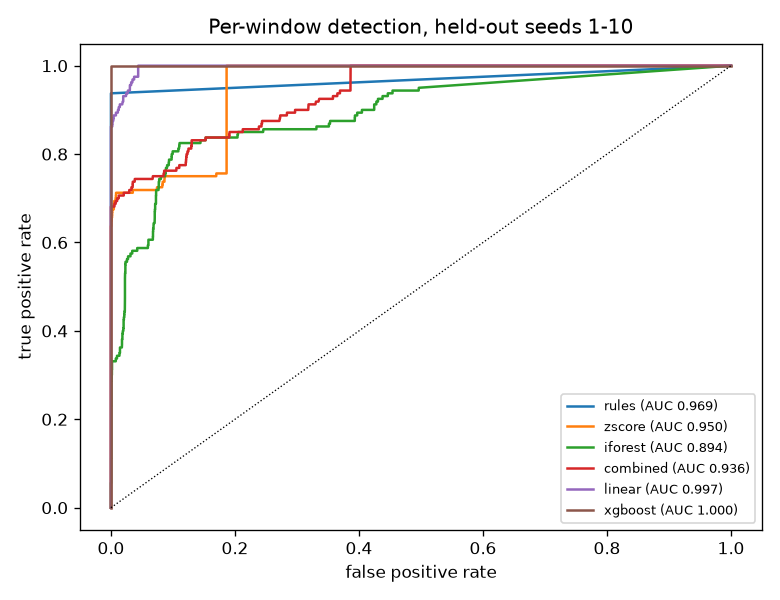

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for method in ["rules", "zscore", "iforest", "combined", "linear", "xgboost"]:
    fpr, tpr, _ = roc_curve(windows.label, windows[method])
    ax.plot(fpr, tpr, label=f"{method} (AUC {summary.loc[method, 'roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k:", lw=0.8)
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("Per-window detection, held-out seeds 1-10")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout(); fig.savefig(OUT / "ablation_roc.png", dpi=120); plt.close(fig)
display(Image(filename=str(OUT / "ablation_roc.png")))

## XGBoost: global SHAP importance (mean |SHAP|, log-odds)

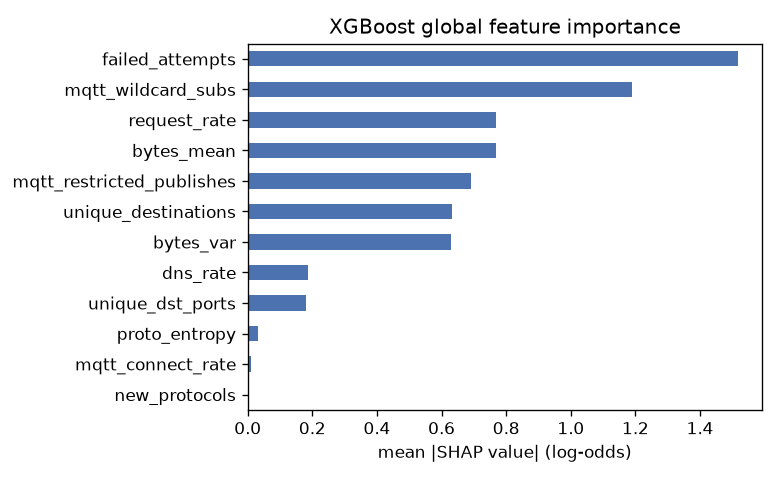

failed_attempts              1.516
mqtt_wildcard_subs           1.191
request_rate                 0.770
bytes_mean                   0.768
mqtt_restricted_publishes    0.692
unique_destinations          0.634
bytes_var                    0.630
dns_rate                     0.187
unique_dst_ports             0.180
proto_entropy                0.033
mqtt_connect_rate            0.010
new_protocols                0.000
dtype: float64

In [5]:
imp = pd.Series(result.xgb_global_importance).sort_values()
fig, ax = plt.subplots(figsize=(6.5, 4))
imp.plot.barh(ax=ax, color="#4c72b0")
ax.set_xlabel("mean |SHAP value| (log-odds)"); ax.set_title("XGBoost global feature importance")
fig.tight_layout(); fig.savefig(OUT / "shap_global.png", dpi=120); plt.close(fig)
display(Image(filename=str(OUT / "shap_global.png")))
imp.sort_values(ascending=False).round(3)

## Findings (computed from the tables above)

In [6]:
s = summary
best_auc = s.roc_auc.idxmax()
lines = [
    f"- Best ranking (ROC-AUC): {best_auc} ({s.roc_auc.max():.4f}).",
    f"- The pipeline as deployed (rules OR combined anomaly score): recall {s.loc['pipeline','recall']:.3f}, "
    f"precision {s.loc['pipeline','precision']:.3f}, FPR {s.loc['pipeline','fpr']:.4f} "
    f"({int(s.loc['pipeline','fp'])} false positives in {int(s.loc['pipeline','fp']+s.loc['pipeline','tn'])} normal windows).",
    f"- Transparent linear scorer (window part): AUC {s.loc['linear','roc_auc']:.4f}, "
    f"recall {s.loc['linear','recall']:.3f} at score >= {s.loc['linear','threshold']:g}, "
    f"FPR {s.loc['linear','fpr']:.4f}.",
    f"- XGBoost (supervised, same generator: upper bound): AUC {s.loc['xgboost','roc_auc']:.4f}, "
    f"recall {s.loc['xgboost','recall']:.3f}, precision {s.loc['xgboost','precision']:.3f}.",
    f"- Isolation Forest alone: AUC {s.loc['iforest','roc_auc']:.4f}, recall {s.loc['iforest','recall']:.3f} "
    f"at its operating point. It cannot split on features that are constant in normal "
    f"training data (wildcard subscriptions, restricted publishes), so those attacks are invisible to it.",
    f"- Rules alone: recall {s.loc['rules','recall']:.3f} with {int(s.loc['rules','fp'])} false positives. "
    f"Per-attack recall shows where the statistical detectors add or miss coverage.",
]
print("\n".join(lines))

- Best ranking (ROC-AUC): xgboost (1.0000).
- The pipeline as deployed (rules OR combined anomaly score): recall 0.969, precision 1.000, FPR 0.0000 (0 false positives in 4600 normal windows).
- Transparent linear scorer (window part): AUC 0.9968, recall 0.887 at score >= 10, FPR 0.0076.
- XGBoost (supervised, same generator: upper bound): AUC 1.0000, recall 1.000, precision 0.994.
- Isolation Forest alone: AUC 0.8936, recall 0.119 at its operating point. It cannot split on features that are constant in normal training data (wildcard subscriptions, restricted publishes), so those attacks are invisible to it.
- Rules alone: recall 0.938 with 0 false positives. Per-attack recall shows where the statistical detectors add or miss coverage.
